In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("bank.csv")
print(df.head())
print(df.dtypes)
print(df.shape)
print(df.describe())



  transaction_id client_id     date_transaction  montant devise  \
0      TXN000559   CLI0060  2022-04-19 02:31:00  2050.42    EUR   
1      TXN001154   CLI0057  2024-06-20 20:51:00  -123.66    GBP   
2      TXN000764   CLI0015  2024-08-28 05:03:00  -396.17    EUR   
3      TXN001598   CLI0045  2024-01-07 08:16:00    225.2    EUR   
4      TXN001873   CLI0034  2024-08-11 19:52:00   935.32    EUR   

   taux_change_eur  montant_eur      categorie              produit  \
0             1.00      2050.42  Depot especes       Compte Epargne   
1             0.86      -143.79    Retrait DAB  Credit Consommation   
2             1.00      -396.17    Prelevement                  PEA   
3             1.00       225.20    Paiement CB  Credit Consommation   
4             1.00       935.32       Interets    Credit Immobilier   

                 agence type_operation    statut  score_credit_client  \
0  Marseille-Vieux-Port         Credit  Complete                  NaN   
1                   NaN 

transaction_id           0.000000
client_id                0.000000
date_transaction         0.000000
montant                  0.000000
devise                   0.000000
taux_change_eur          0.000000
montant_eur              0.000000
categorie                0.000000
produit                  0.000000
agence                   3.106796
type_operation           0.000000
statut                   0.000000
score_credit_client      8.106796
segment_client           5.097087
solde_avant              0.000000
taux_interet           100.000000
dtype: float64


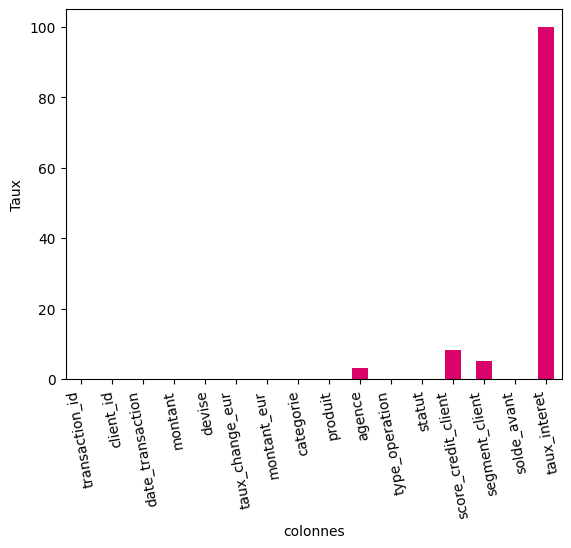

In [2]:
taux_nan = (df.isna().sum()/len(df))*100
print(taux_nan)
taux_nan.plot(kind="bar",color="#d9036a")
plt.xlabel("colonnes")
plt.ylabel("Taux")
plt.xticks(rotation = 100)
plt.show()
doublon = df.drop_duplicates(subset="transaction_id",keep="first")

In [3]:
#2️ Nettoyage des données
df["date_transaction"] = pd.to_datetime(
    df["date_transaction"],
    errors="coerce"
)
# unformiser le format
df["date_transaction"] =df["date_transaction"].dt.strftime("%Y-%m-%d %H:%M:%S")
df['date_transaction']
print(df.dtypes)
#Montants avec séparateur décimal incorrect 
df["montant"]=df["montant"].str.replace(',','.')
#Nettoyer la colonne solde_avant : supprimer le suffixe texte ' EUR', convertir en float
df["solde_avant"]=df['solde_avant'].str.replace("EUR","").str.replace(',','.')
df["solde_avant"]=pd.to_numeric(df["solde_avant"],errors='coerce')
#Harmoniser segment_client 
df["segment_client"] = df["segment_client"].str.capitalize()
#Supprimer les espaces parasites sur la colonne agence
df["agence"] = df["agence"].str.strip()
#Traiter les valeurs manquantes
col_num = df.select_dtypes(include = "float64").columns
for col in col_num:
    df[col]=df[col].fillna(df[col].median())

col_catg = df.select_dtypes(include="string").columns
for col in col_catg:
    df[col]=df[col].fillna(df[col].mode()[0])

transaction_id          object
client_id               object
date_transaction        object
montant                 object
devise                  object
taux_change_eur        float64
montant_eur            float64
categorie               object
produit                 object
agence                  object
type_operation          object
statut                  object
score_credit_client    float64
segment_client          object
solde_avant             object
taux_interet           float64
dtype: object


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1213: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [4]:
#3 Détection & Traitement des Valeurs Aberrantes
 # Montant
df["montant"] = pd.to_numeric(df["montant"] , errors = 'coerce')
Q1 = df['montant'].quantile(0.25)
Q3 = df['montant'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Score crédit

Q1_s = df['score_credit_client'].quantile(0.25)
Q3_s = df['score_credit_client'].quantile(0.75)
IQR_s = Q3_s - Q1_s
lower_s = Q1_s - 1.5 * IQR_s
upper_s = Q3_s + 1.5 * IQR_s

# Flag anomalies

df['is_anomaly'] = (
    (df['montant'] < lower) | (df['montant'] > upper) |
    (df['score_credit_client'] < 0) | (df['score_credit_client'] > 850)
)

print("Nombre anomalies détectées :", df['is_anomaly'].sum())




Nombre anomalies détectées : 117


In [5]:
#4Feature Engineering
#Extraire depuis date_transaction 
df["date_transaction"] = pd.to_datetime(df["date_transaction"], errors="coerce")
df["annees"] = df["date_transaction"].dt.year
df["mois"] = df["date_transaction"].dt.month
df["jours_semaine"] = df["date_transaction"].dt.day_name()
df["trimestre"] = df["date_transaction"].dt.quarter
#Calculer montant_eur_verifie
df["montant_eur_ver"] = df["montant"] / df["taux_change_eur"]
df["diff"] = df["montant_eur_ver"] - df["montant_eur"]
print(df["diff"])
# creation de categorie_risque 
df["categorie_risque"] = pd.cut(
    df["score_credit_client"],
    bins=[0, 580, 700, float("inf")],
    labels=["High", "Medium", "Low"]

)
#Agréger par client 
df_clients = df.groupby("client_id").agg({
    "client_id": "count",     
    "montant": "mean",        
    "produit": "nunique"    
}).rename(columns={
    "client_id": "nb_transactions",
    "montant": "montant_moyen",
    "produit": "nb_produits_distincts"
})
# Création de taux_rejet 
taux_rejet_agence = df.groupby("agence").agg(
    nb_rejets=("statut", lambda x: (x == "rejetée").sum()),  
    nb_total=("statut", "count")                               
)

taux_rejet_agence["taux_rejet"] = taux_rejet_agence["nb_rejets"] / taux_rejet_agence["nb_total"]

0       0.000000
1      -0.000698
2       0.000000
3       0.000000
4       0.000000
          ...   
2055    0.000000
2056    0.000000
2057    0.000000
2058   -0.000412
2059    0.001481
Name: diff, Length: 2060, dtype: float64


In [6]:
#5 exportation 
print(df.isnull().sum())
print(df.dtypes)
print(df.describe())
print(df['categorie_risque'].value_counts())
# Exporter le dataset final en CSV
df.to_csv("financecore_clean.csv", index=False)

transaction_id            0
client_id                 0
date_transaction         80
montant                   0
devise                    0
taux_change_eur           0
montant_eur               0
categorie                 0
produit                   0
agence                   64
type_operation            0
statut                    0
score_credit_client       0
segment_client          105
solde_avant               0
taux_interet           2060
is_anomaly                0
annees                   80
mois                     80
jours_semaine            80
trimestre                80
montant_eur_ver           0
diff                      0
categorie_risque          2
dtype: int64
transaction_id                 object
client_id                      object
date_transaction       datetime64[ns]
montant                       float64
devise                         object
taux_change_eur               float64
montant_eur                   float64
categorie                      object
produit    

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2060 entries, 0 to 2059
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transaction_id       2060 non-null   object        
 1   client_id            2060 non-null   object        
 2   date_transaction     1980 non-null   datetime64[ns]
 3   montant              2060 non-null   float64       
 4   devise               2060 non-null   object        
 5   taux_change_eur      2060 non-null   float64       
 6   montant_eur          2060 non-null   float64       
 7   categorie            2060 non-null   object        
 8   produit              2060 non-null   object        
 9   agence               1996 non-null   object        
 10  type_operation       2060 non-null   object        
 11  statut               2060 non-null   object        
 12  score_credit_client  2060 non-null   float64       
 13  segment_client       1955 non-nul